# Figure 4 — convergence of I to FR as alpha_D increases

Renders `fig4.{pdf,png}`: 1-D slice of the Fisher-Rao energy `I(y)` over the
sinusoid manifold, plain FR as reference vs. Bayesian FR swept over concentration `alpha_D`.
Two panels, `k=5` and `k=10` neighbours. Cheap: no model, no sampling.

Reduced from `experiments/sinusoid/04_bayesian_fr_1d_slice.ipynb` to the two methods reported,
re-pointed at the real N=10 atoms Figure 6 (sinusoid) trained/guided against. `k=10` retrieves all 10
atoms (no-retrieval limit), useful beside `k=5` to separate the prior's effect from retrieval's.

In [1]:
import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO = os.path.abspath("../..")
sys.path.insert(0, os.path.join(REPO, "src"))
sys.path.insert(0, os.path.join(REPO, "workshop_figures"))

from guidance import basic_fr, bayesian_fr
import wsstyle

mpl_fs = 19
wsstyle.use_style(font_size=mpl_fs)

In [2]:
CKPT = os.path.join(REPO, "experiments", "sinusoid", "checkpoints", "score_normal_N10.pt")

# "manifold": query points ride on the curve (x-axis = curve parameter u), so every energy
# valley lands on a real atom. "horizontal": the line y=0, atoms sit off the slice.
SLICE = "manifold"

T_SLICE = 0.1          # late diffusion time, as in Figure 1b
Q_TARGET = 0.9         # matches Figure 1's experiment
K_GRID = [5, 10]
ALPHA_GRID = [0.1, 0.25, 0.5, 1.0]
B_BOOTSTRAP = 256
N_QUERY = 1600

ckpt = torch.load(CKPT, weights_only=False)
tc = ckpt["config"]
X_atoms = ckpt["X_target"].cpu()
BETA_MIN, BETA_MAX = tc["beta_min"], tc["beta_max"]
N_ATOMS = X_atoms.shape[0]


def alpha_bar(t):
    t = torch.as_tensor(t, dtype=torch.float32)
    return torch.exp(-(BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2))


def sigma2(t):
    return (1.0 - alpha_bar(t)).clamp(min=1e-6)


S2 = sigma2(T_SLICE)

U_LO, U_HI = -3.1, 2.9
u_grid = torch.linspace(U_LO, U_HI, N_QUERY)
if SLICE == "manifold":
    Z = torch.stack([u_grid, 0.6 * torch.sin(2 * u_grid)], dim=-1)
else:
    Z = torch.stack([u_grid, torch.zeros_like(u_grid)], dim=-1)
beta_t = S2.expand(Z.shape[0])

print(f"atoms N={N_ATOMS}  slice={SLICE}  t={T_SLICE}  sigma^2={S2.item():.4f}  q_target={Q_TARGET}")
print(f"alpha_D grid {ALPHA_GRID}   B={B_BOOTSTRAP}   k grid {K_GRID}")

atoms N=10  slice=manifold  t=0.1  sigma^2=0.1037  q_target=0.9
alpha_D grid [0.1, 0.25, 0.5, 1.0]   B=256   k grid [5, 10]


## Energies

Both methods share retrieval and softmax temperature, so at any query point they receive an
identical `beta` and differ only in the posterior built from it.

In [3]:
def knn(k):
    """Top-k atoms per query point, with global indices identifying the Voronoi cell."""
    d2 = torch.cdist(Z, X_atoms) ** 2
    sq_d, idx = torch.topk(d2, k, largest=False, dim=1)
    return X_atoms[idx], sq_d, idx


def curves_for(k):
    neighbors, sq_d, idx = knn(k)
    beta_soft = basic_fr.beta_soft_for(sq_d, Q_TARGET)

    I_fr, q_fr, _ = basic_fr.fisher_rao_energy(Z, neighbors, beta_t, beta_soft=beta_soft)

    bayes = {}
    for a in ALPHA_GRID:
        I_b, _, _ = bayesian_fr.fisher_rao_energy_bb(
            Z, neighbors, beta_t, B=B_BOOTSTRAP, dirichlet_alpha=a, beta_soft=beta_soft)
        bayes[a] = I_b.detach().numpy()

    # cell walls: where the posterior's argmax switches owner (global index, not k-set rank)
    owner = idx.gather(1, q_fr.argmax(1, keepdim=True)).squeeze(1).numpy()
    walls = u_grid.numpy()[:-1][owner[:-1] != owner[1:]]
    return {"fr": I_fr.detach().numpy(), "bayes": bayes, "walls": walls, "owner": owner}


results = {k: curves_for(k) for k in K_GRID}
for k, r in results.items():
    peak = max(r["fr"].max(), max(c.max() for c in r["bayes"].values()))
    print(f"k={k:>3}  cell walls on the slice: {len(r['walls']):>2}   peak I = {peak:.3g}")

k=  5  cell walls on the slice:  9   peak I = 90.7
k= 10  cell walls on the slice:  9   peak I = 89


## Render

House style: no hyperparameters in the panels, one legend outside every axes, light rule
grid, Times. `alpha_D` runs light-to-dark so the ordering reads without the legend.

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/out/fig4.pdf', '/Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/out/fig4.png']


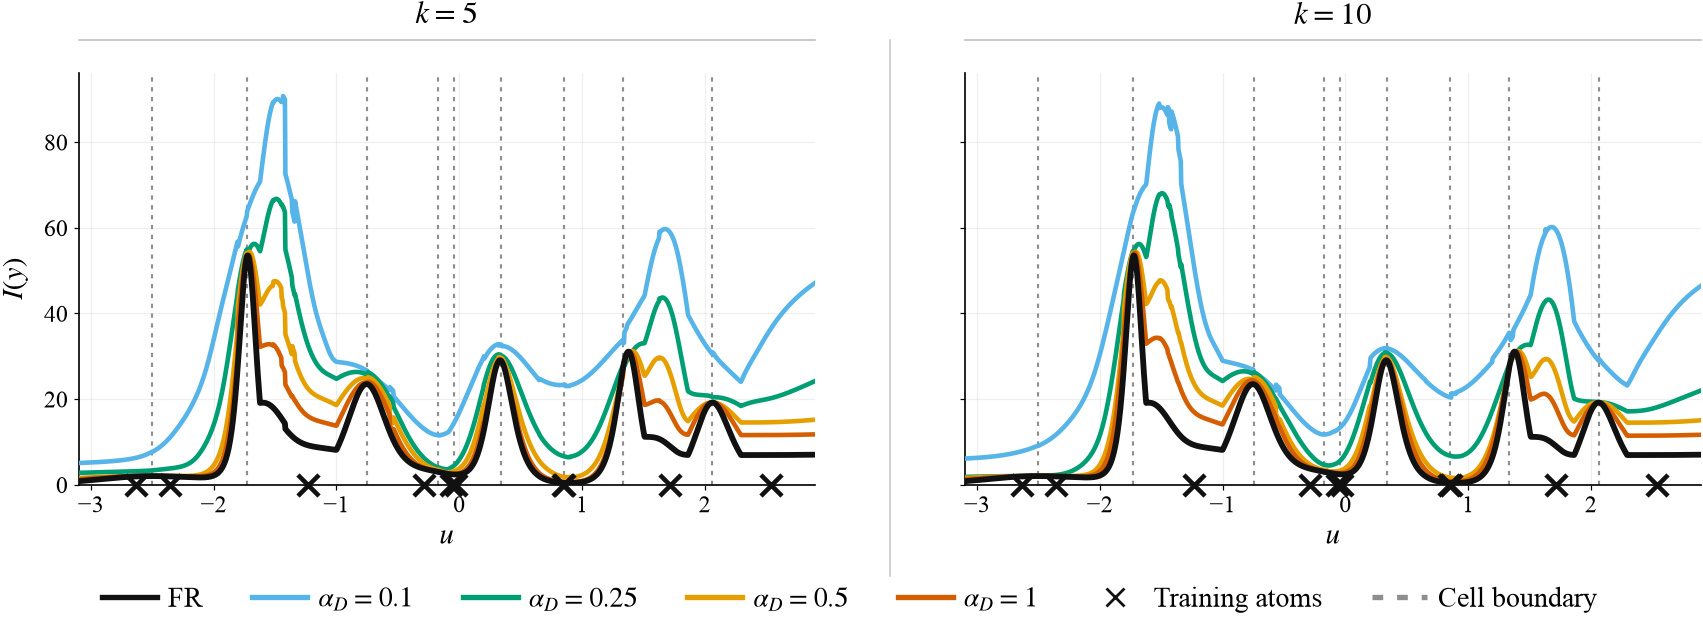

In [4]:
# distinct hues (not shades) so overlapping/crossing curves stay separable
ALPHA_COLORS = [wsstyle.OKABE_ITO["skyblue"],
                wsstyle.OKABE_ITO["green"],
                wsstyle.OKABE_ITO["orange"],
                wsstyle.OKABE_ITO["vermilion"]]
FR_COLOR = "#111111"
WALL_COLOR = "#8E8E8E"
ATOM_COLOR = "#111111"

fig = plt.figure(figsize=(16.0, 6.4))
axes, blocks, block_rects = wsstyle.place_grid(
    fig, n_rows=1, block_sizes=[1] * len(K_GRID),
    left=0.062, right=0.016, top=0.815, bottom=0.230,
    block_gap=0.085, panel_gap=0.030, row_gap=0.0)

for j, k in enumerate(K_GRID):
    ax = axes[0][j]
    r = results[k]

    for w in r["walls"]:
        ax.axvline(w, color=WALL_COLOR, lw=1.4, ls=(0, (2, 2.6)), zorder=0)

    for a, col in zip(ALPHA_GRID, ALPHA_COLORS):
        ax.plot(u_grid.numpy(), r["bayes"][a], color=col, lw=3.0, zorder=3)
    ax.plot(u_grid.numpy(), r["fr"], color=FR_COLOR, lw=3.8, zorder=4)

    ax.scatter(X_atoms[:, 0].numpy(), np.zeros(N_ATOMS), s=190,
               marker="x", color=ATOM_COLOR, linewidths=3.0,
               clip_on=False, zorder=6)

    wsstyle.grid_on(ax)
    ax.set_xlim(U_LO, U_HI)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("$u$" if SLICE == "manifold" else "$x$")
    if j == 0:
        ax.set_ylabel("$I(y)$", labelpad=10)
    else:
        ax.tick_params(labelleft=False)

# shared y-scale: the point is how far each prior pulls the curve down
wsstyle.match_limits(axes[0], xlim=(U_LO, U_HI),
                     ylim=(0, max(max(r["fr"].max(), max(c.max() for c in r["bayes"].values()))
                                  for r in results.values()) * 1.06))

rule_ys = []
for k, block, rect in zip(K_GRID, blocks, block_rects):
    flat = wsstyle.flatten(block)
    y = wsstyle.block_header(fig, flat, rf"$k = {k}$", x_extent=rect, dy=0.060)
    wsstyle.header_rule(fig, rect, y - 0.014)
    rule_ys.append(y - 0.014)

y_bottom = min(ax.get_position().y0 for ax in wsstyle.flatten(axes)) - 0.130
for x in wsstyle.gutter_positions(block_rects):
    wsstyle.separator(fig, x, y_bottom, max(rule_ys), color="#C4C4C4")

entries = [("FR", "line", FR_COLOR)]
entries += [(rf"$\alpha_D = {a:g}$", "line", col) for a, col in zip(ALPHA_GRID, ALPHA_COLORS)]
entries += [("Training atoms", "cross", ATOM_COLOR),
            ("Cell boundary", "line", WALL_COLOR, (0, (2, 2.6)))]
wsstyle.figure_legend(fig, entries, ncol=len(entries), y=0.120, loc="upper center")

print(wsstyle.save(fig, "fig4"))